# 01 — Exploratory Data Analysis
**Project:** Paper.id Fraud Detection
**Goal:** Memahami distribusi data, pola transaksi, dan sinyal awal fraud.

## 0. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
from src.data.loader import load_all

data = load_all()
transactions = data['transactions']
company      = data['company']
request      = data['request']
promotion    = data['promotion']

print('transactions :', transactions.shape)
print('company      :', company.shape)
print('request      :', request.shape)
print('promotion    :', promotion.shape)

transactions : (50000, 9)
company      : (50000, 11)
request      : (50000, 3)
promotion    : (50000, 4)


## 1. Overview Dataset

In [3]:
for name, df in data.items():
    print(f'\n=== {name} ===')
    print(df.dtypes)
    print('Missing values:')
    print(df.isnull().sum()[df.isnull().sum() > 0])


=== transactions ===
dpt_id                                  object
dpt_promotion_id                        object
buyer_id                                object
seller_id                               object
transaction_amount                     float64
payment_method_name                     object
payment_provider_name                   object
transaction_created_datetime    datetime64[ns]
transaction_updated_datetime    datetime64[ns]
dtype: object
Missing values:
dpt_promotion_id    49063
dtype: int64

=== company ===
company_id                             object
company_kyc_status_name                object
company_kyb_status_name                object
company_type_group                     object
company_phone_verified_flag           float64
company_email_verified_flag           float64
user_fraud_flag                       float64
testing_account_flag                  float64
blacklist_account_flag                float64
package_active_name                    object
company_r

In [4]:
transactions.head()

,dpt_id,dpt_promotion_id,buyer_id,seller_id,transaction_amount,payment_method_name,payment_provider_name,transaction_created_datetime,transaction_updated_datetime
0,69e9566b3f4d6cb7db2216121b0cd0308c516e680e9c78...,NaN,bbce610a3267808752a7ec263a7ecfbe76a4987d529bcb...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,20380.0,MITRA_PEMBAYARAN_DIGITAL,BLIBLI,2023-08-16 09:00:53.297729,2023-08-16 10:24:56.875352
1,961d6f7efde3622da8f35e76e2b53acd84c647a661de86...,NaN,09eb3b80abae1238ef39d50b66215e02e1ac9891ad6e8f...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,14673.6,MITRA_PEMBAYARAN_DIGITAL,BLIBLI,2023-06-09 15:22:49.867524,2023-06-09 15:23:42.718184
2,6441defc089b4ae947cce529904a5c7db2326ede52bdaa...,NaN,25d0774533d69564d0deca724a55a76c693ed5f7ffa12a...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,1012500.0,MITRA_PEMBAYARAN_DIGITAL,TOKOPEDIA,2023-10-08 10:45:24.139583,2023-10-09 11:47:23.938359
3,64152dd86b2c5d1af6aaa911e7a229dc539273e0a7b8be...,NaN,5b846313375cb4f4d065e50a05833dc3ac20ba3f532bbe...,5b846313375cb4f4d065e50a05833dc3ac20ba3f532bbe...,30000.0,MITRA_PEMBAYARAN_DIGITAL,BLIBLI,2023-05-26 13:41:27.133014,2023-05-26 13:47:40.595121
4,ae4ddde99c8fe7f73fb3c2ee0e157e886b52417ece17bd...,NaN,5c19a13a9b229340b584f621b648f4dec7491e12368392...,5c19a13a9b229340b584f621b648f4dec7491e12368392...,1000008.0,MITRA_PEMBAYARAN_DIGITAL,TOKOPEDIA,2023-05-26 17:29:34.201724,2023-05-26 17:30:04.688498


## 2. Distribusi Nilai Transaksi

In [5]:
print(transactions['transaction_amount'].describe())
print(f"Skewness : {transactions['transaction_amount'].skew():.4f}")
print(f"Kurtosis : {transactions['transaction_amount'].kurt():.4f}")

count    5.000000e+04
mean     1.965125e+07
std      1.057004e+08
min      0.000000e+00
25%      7.000043e+04
50%      1.850172e+06
75%      1.398597e+07
max      2.014010e+10
Name: transaction_amount, dtype: float64
Skewness : 139.0426
Kurtosis : 26266.2539


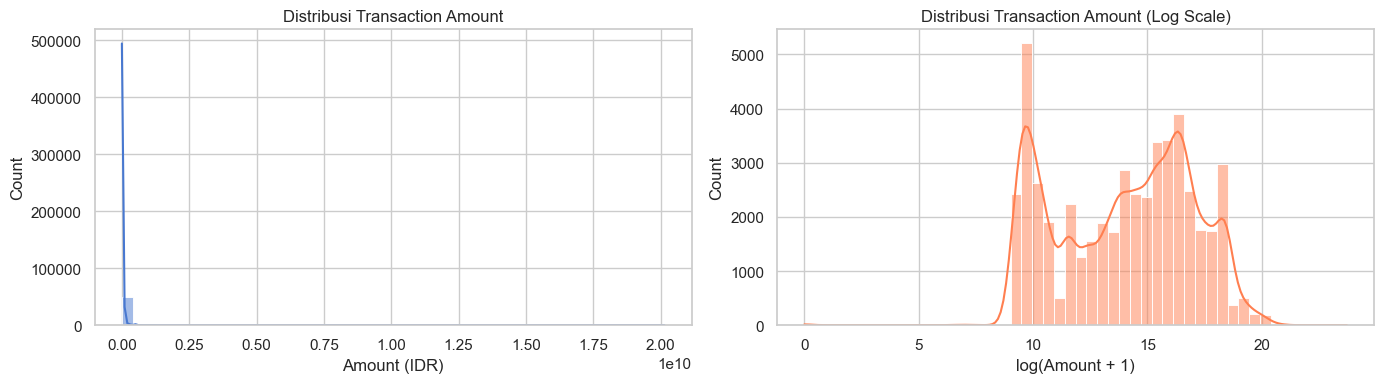

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(transactions['transaction_amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Transaction Amount')
axes[0].set_xlabel('Amount (IDR)')

sns.histplot(np.log1p(transactions['transaction_amount']), bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribusi Transaction Amount (Log Scale)')
axes[1].set_xlabel('log(Amount + 1)')

plt.tight_layout()
plt.savefig('../reports/fig_transaction_amount_dist.png', dpi=150)
plt.show()

## 3. Tren Transaksi per Waktu

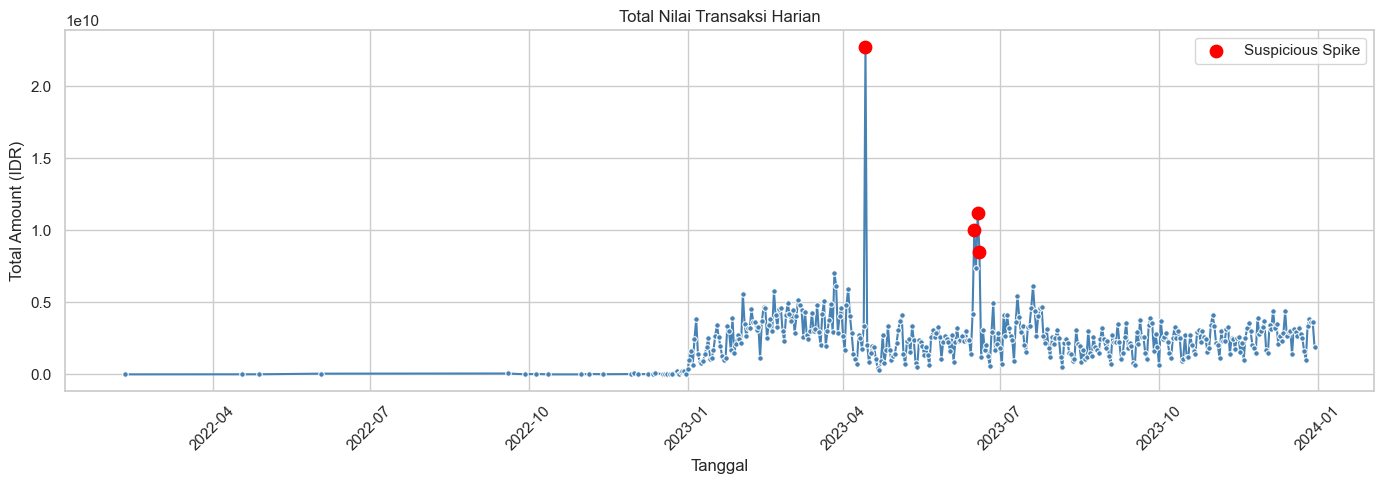

Jumlah hari dengan spike mencurigakan: 4


In [7]:
daily = transactions.groupby(transactions['transaction_created_datetime'].dt.date)['transaction_amount'].sum().reset_index()
daily.columns = ['date', 'total_amount']

mean_amt = daily['total_amount'].mean()
std_amt  = daily['total_amount'].std()
daily['suspicious_spike'] = daily['total_amount'] > mean_amt + 3 * std_amt

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x='date', y='total_amount', color='steelblue', marker='o', markersize=4)
plt.scatter(
    daily[daily['suspicious_spike']]['date'],
    daily[daily['suspicious_spike']]['total_amount'],
    color='red', s=80, zorder=5, label='Suspicious Spike'
)
plt.title('Total Nilai Transaksi Harian')
plt.xlabel('Tanggal')
plt.ylabel('Total Amount (IDR)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/fig_daily_transaction_trend.png', dpi=150)
plt.show()

print(f"Jumlah hari dengan spike mencurigakan: {daily['suspicious_spike'].sum()}")

## 4. Analisis Metode & Provider Pembayaran

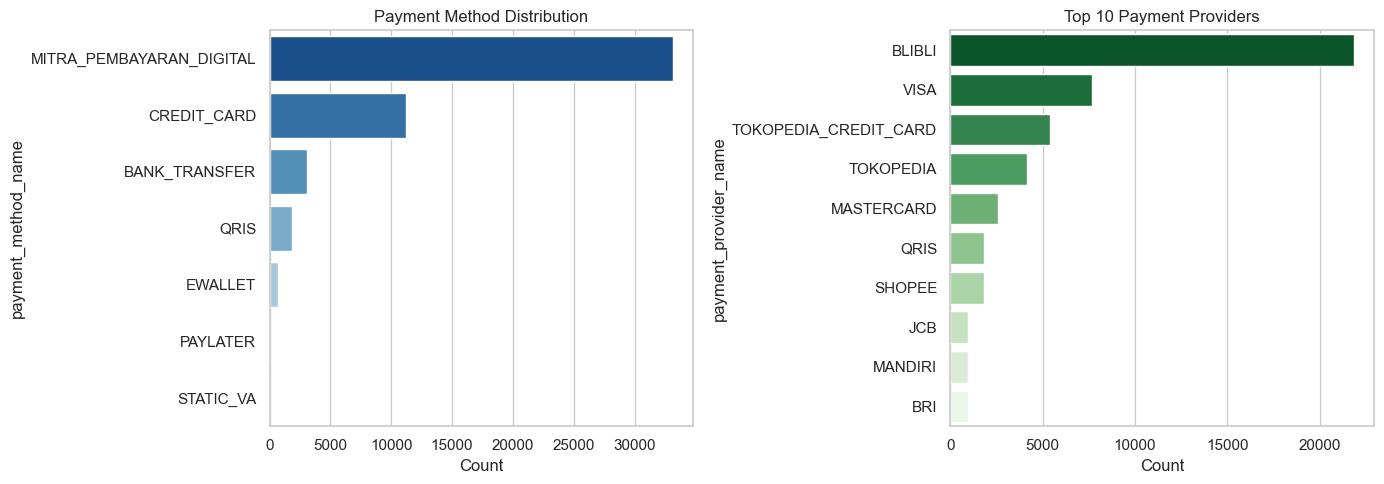

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

method_counts = transactions['payment_method_name'].value_counts()
sns.barplot(x=method_counts.values, y=method_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Payment Method Distribution')
axes[0].set_xlabel('Count')

provider_counts = transactions['payment_provider_name'].value_counts().head(10)
sns.barplot(x=provider_counts.values, y=provider_counts.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Payment Providers')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../reports/fig_payment_distribution.png', dpi=150)
plt.show()

## 5. Analisis Fraud & Blacklist (Company)

In [9]:
fraud_counts     = company['user_fraud_flag'].value_counts()
blacklist_counts = company['blacklist_account_flag'].value_counts()

print('user_fraud_flag:')
print(fraud_counts)
print(f'  Fraud rate: {fraud_counts.get(1, 0) / len(company) * 100:.2f}%')

print('\nblacklist_account_flag:')
print(blacklist_counts)
print(f'  Blacklist rate: {blacklist_counts.get(1, 0) / len(company) * 100:.2f}%')

user_fraud_flag:
user_fraud_flag
0.0    42350
1.0     7650
Name: count, dtype: int64
  Fraud rate: 15.30%

blacklist_account_flag:
blacklist_account_flag
0.0    49962
1.0       38
Name: count, dtype: int64
  Blacklist rate: 0.08%


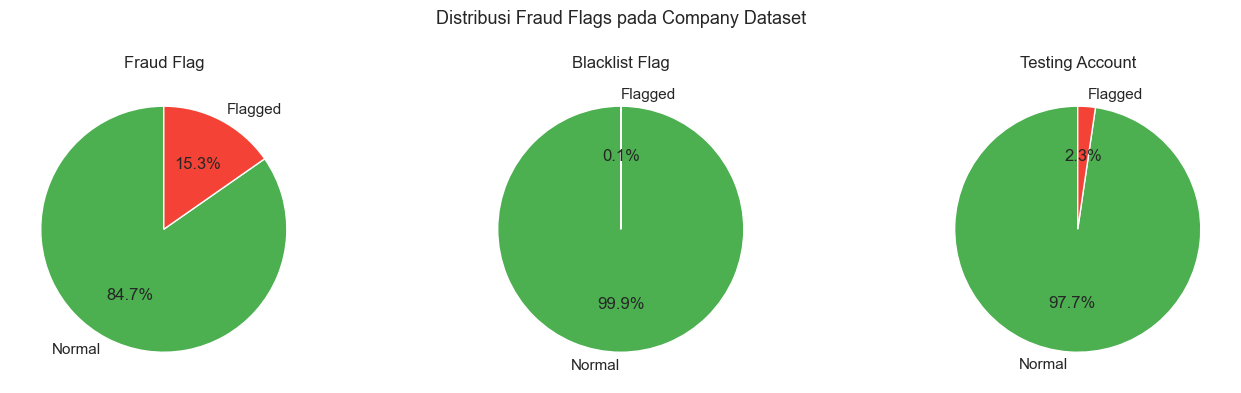

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ['user_fraud_flag', 'blacklist_account_flag', 'testing_account_flag'],
    ['Fraud Flag', 'Blacklist Flag', 'Testing Account']):
    counts = company[col].value_counts()
    ax.pie(counts, labels=['Normal', 'Flagged'], autopct='%1.1f%%',
           colors=['#4CAF50', '#F44336'], startangle=90)
    ax.set_title(title)

plt.suptitle('Distribusi Fraud Flags pada Company Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/fig_fraud_flags.png', dpi=150)
plt.show()

## 6. Top Buyer-Seller Pairs (Frekuensi Tinggi)

Total pasangan buyer-seller unik: 10354
Max transaksi dalam 1 pasangan  : 1266
Median                          : 2.0


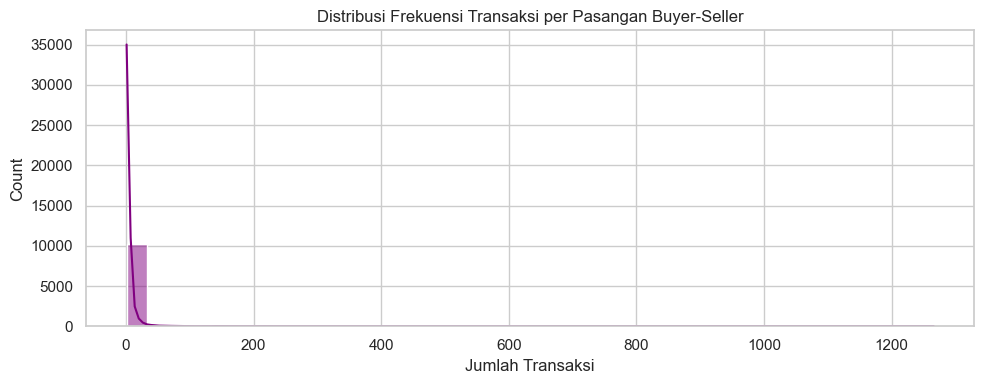


Top 10 pasangan:


,buyer_id,seller_id,count
470,0bb440f2ae8461ca7b424f9b0efddbb2a1993e07a6d629...,0bb440f2ae8461ca7b424f9b0efddbb2a1993e07a6d629...,1266
698,10f3200ad77826457a7b33726d1ec95de21ee6400745aa...,10f3200ad77826457a7b33726d1ec95de21ee6400745aa...,321
2112,34d1c64bbd54c2912026f19d45b7274b31f3e5f3ca9a81...,34d1c64bbd54c2912026f19d45b7274b31f3e5f3ca9a81...,294
7292,b4c5286fbf6443dd4df37457f3ef23a2b71253b1c86452...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,294
5998,9506dece8982a8d50fbb2924dd510825ea1516c19852aa...,9506dece8982a8d50fbb2924dd510825ea1516c19852aa...,261
1349,2155a0b3ec4ef3cb18f0890eab8177381c7e96dad96297...,2155a0b3ec4ef3cb18f0890eab8177381c7e96dad96297...,248
8984,df43724682fbd651e549d3e2043a9d0d2cc4700545863a...,df43724682fbd651e549d3e2043a9d0d2cc4700545863a...,243
91,02611e2fdd7d730bddbd654baf24f03a739704bcb34c01...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,216
8985,df49a12bd4d8e5cc564d587ddf36c8b15be260b4b048e8...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,215
290,0719f2ed66328a141dc1807848bcc72edd027567ae4fc4...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,210


In [11]:
pair_freq = transactions.groupby(['buyer_id', 'seller_id']).size().reset_index(name='count')
pair_freq = pair_freq.sort_values('count', ascending=False)

print(f'Total pasangan buyer-seller unik: {len(pair_freq)}')
print(f'Max transaksi dalam 1 pasangan  : {pair_freq["count"].max()}')
print(f'Median                          : {pair_freq["count"].median()}')

plt.figure(figsize=(10, 4))
sns.histplot(pair_freq['count'], bins=40, kde=True, color='purple')
plt.title('Distribusi Frekuensi Transaksi per Pasangan Buyer-Seller')
plt.xlabel('Jumlah Transaksi')
plt.tight_layout()
plt.savefig('../reports/fig_buyer_seller_freq.png', dpi=150)
plt.show()

print('\nTop 10 pasangan:')
pair_freq.head(10)

## 7. Analisis Penggunaan Promosi

Transaksi tanpa promosi: 98.1%


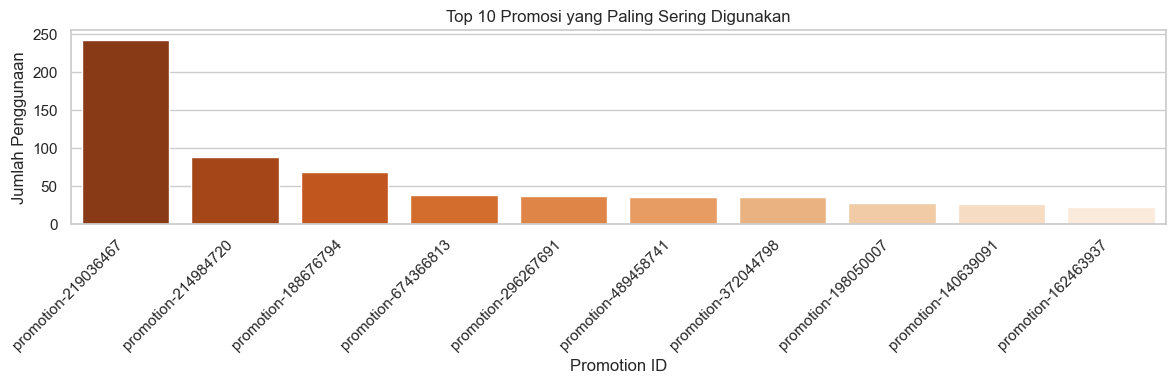

In [12]:
promo_usage = transactions['dpt_promotion_id'].value_counts().reset_index()
promo_usage.columns = ['promotion_id', 'usage_count']

no_promo_pct = (transactions['dpt_promotion_id'].isna().sum() / len(transactions)) * 100
print(f'Transaksi tanpa promosi: {no_promo_pct:.1f}%')

plt.figure(figsize=(12, 4))
sns.barplot(data=promo_usage.head(10), x='promotion_id', y='usage_count', palette='Oranges_r')
plt.title('Top 10 Promosi yang Paling Sering Digunakan')
plt.xlabel('Promotion ID')
plt.ylabel('Jumlah Penggunaan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/fig_promo_usage.png', dpi=150)
plt.show()

## 8. Summary Temuan EDA

In [13]:
print('=== SUMMARY EDA ===')
print(f'Total transaksi          : {len(transactions):,}')
print(f'Rentang waktu            : {transactions["transaction_created_datetime"].min().date()} s/d {transactions["transaction_created_datetime"].max().date()}')
print(f'Rata-rata nilai transaksi: Rp {transactions["transaction_amount"].mean():,.0f}')
print(f'Median nilai transaksi   : Rp {transactions["transaction_amount"].median():,.0f}')
print(f'Total company            : {len(company):,}')
print(f'Fraud flag rate          : {company["user_fraud_flag"].mean() * 100:.2f}%')
print(f'Blacklist rate           : {company["blacklist_account_flag"].mean() * 100:.2f}%')

=== SUMMARY EDA ===
Total transaksi          : 50,000
Rentang waktu            : 2022-02-09 s/d 2023-12-30
Rata-rata nilai transaksi: Rp 19,651,245
Median nilai transaksi   : Rp 1,850,172
Total company            : 50,000
Fraud flag rate          : 15.30%
Blacklist rate           : 0.08%
